In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score, confusion_matrix, classification_report, precision_recall_curve, recall_score
from sklearn.model_selection import learning_curve, GridSearchCV, train_test_split, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.pipeline import make_pipeline
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LogisticRegression

In [60]:
dataset_path = dataset_path = "C:/Users/tamer/.cache/kagglehub/datasets/uciml/breast-cancer-wisconsin-data/versions/2/data.csv"
df = pd.read_csv(dataset_path)

In [61]:
df = df.drop('Unnamed: 32', axis=1)

In [62]:
pd.set_option("display.max_row",33)
pd.set_option("display.max_column",33)

In [63]:
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


# 1) Exploratory dataset

float64    30
int64       1
object      1
Name: count, dtype: int64


<Axes: ylabel='count'>

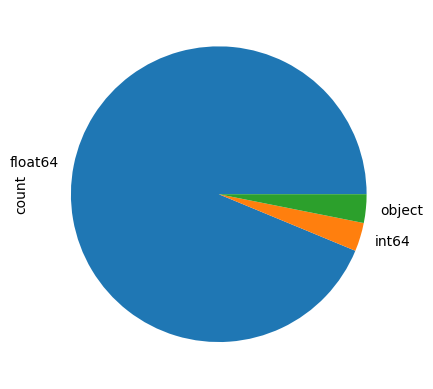

In [64]:
print(df.dtypes.value_counts())
df.dtypes.value_counts().plot.pie() # => pie chart

<Axes: >

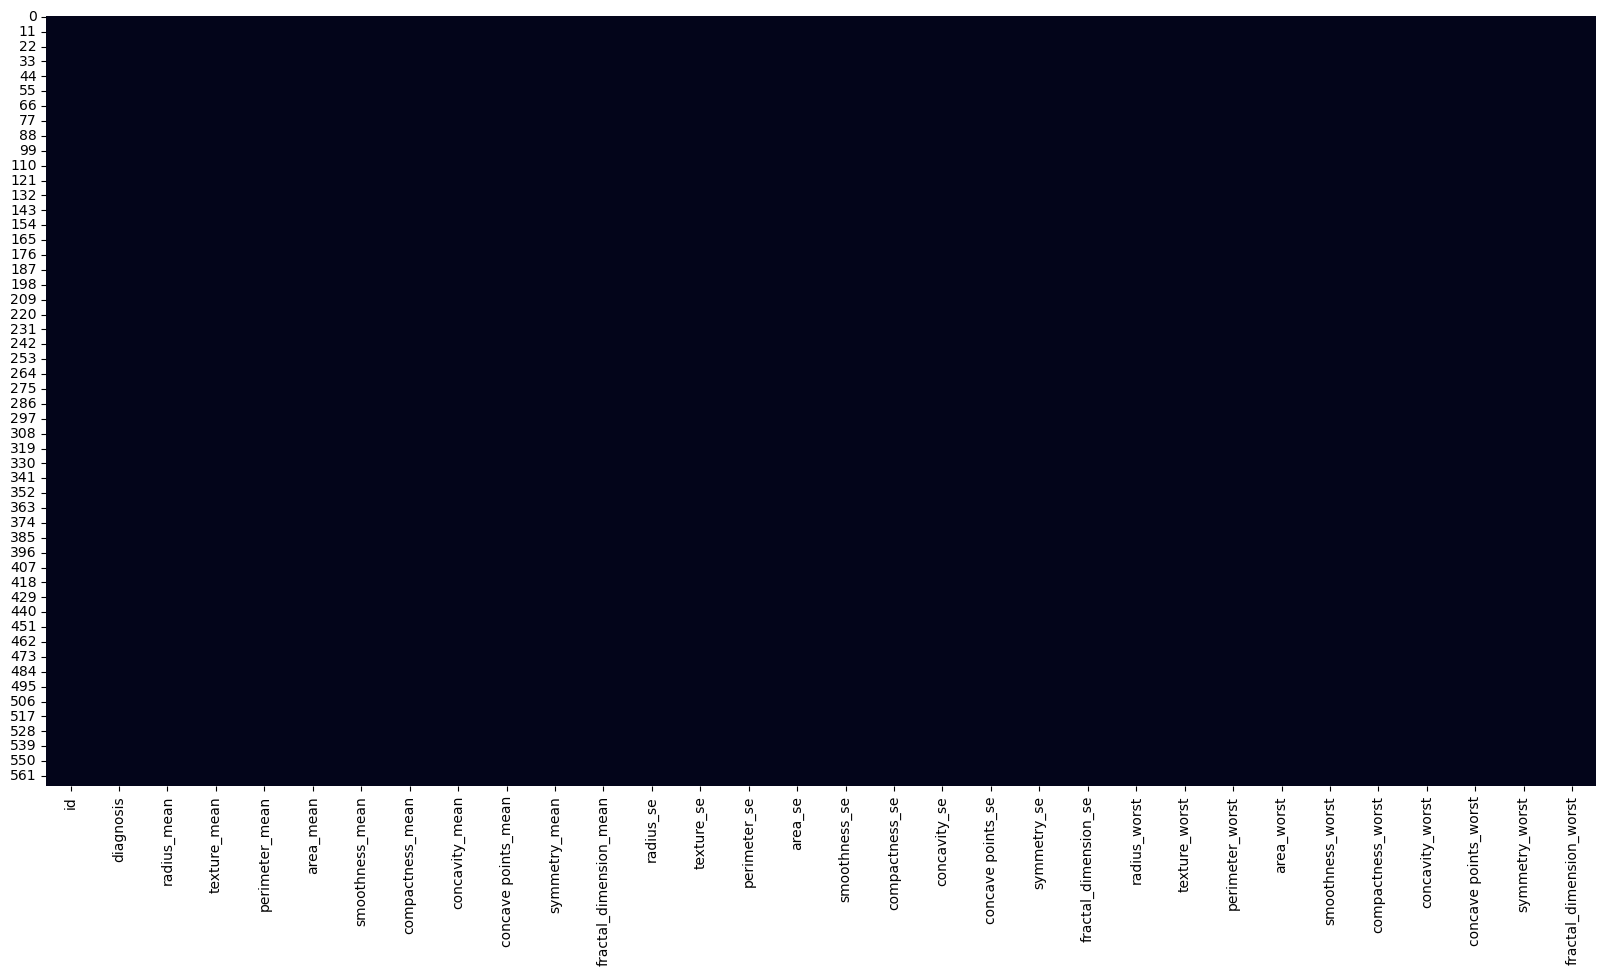

In [65]:
plt.figure(figsize=(20,10))
sns.heatmap(df.isna(), cbar = False)

In [66]:
# Notes 
# Pas de valeurs manquantes
# que des variables continues

In [67]:
print(df['diagnosis'].value_counts())
print(df['diagnosis'].value_counts(normalize = True)) # Pourcentages

diagnosis
B    357
M    212
Name: count, dtype: int64
diagnosis
B    0.627417
M    0.372583
Name: proportion, dtype: float64


In [68]:
df_M = df[df['diagnosis'] == 'M']
df_B = df[df['diagnosis'] == 'B']

## Analyse de la distribution des variables

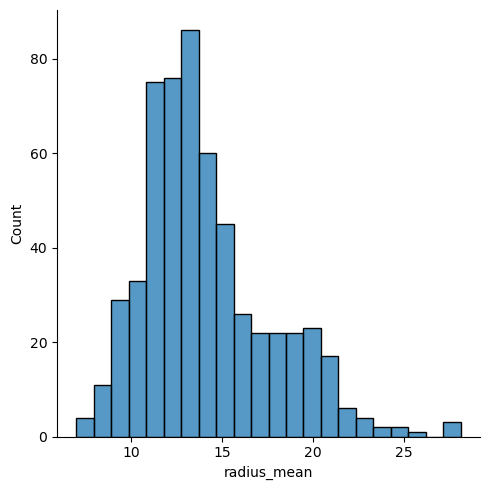

In [69]:
sns.displot(df['radius_mean'])

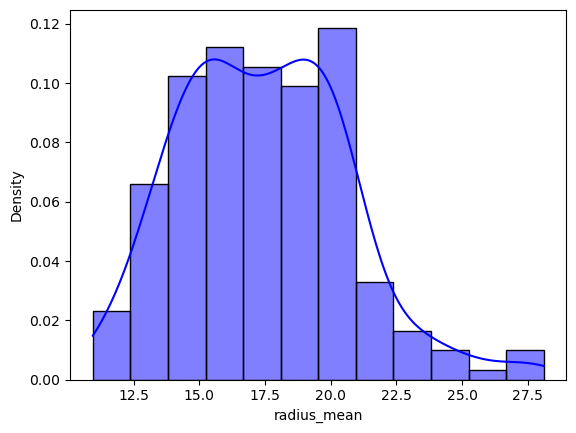

In [70]:
plt.figure()  # create new figure for each variable
sns.histplot(df_M['radius_mean'], color='blue', kde=True, stat='density')
plt.show()

## Corrélation entre target et variables

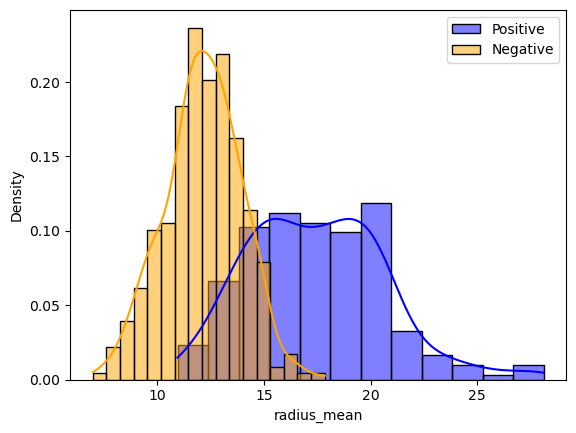

In [71]:
plt.figure()  # create new figure for each variable
sns.histplot(df_M['radius_mean'], label='Positive', color='blue', kde=True, stat='density')
sns.histplot(df_B['radius_mean'], label='Negative', color='orange', kde=True, stat='density')
plt.legend()
plt.show()

## Corrélation entre variables

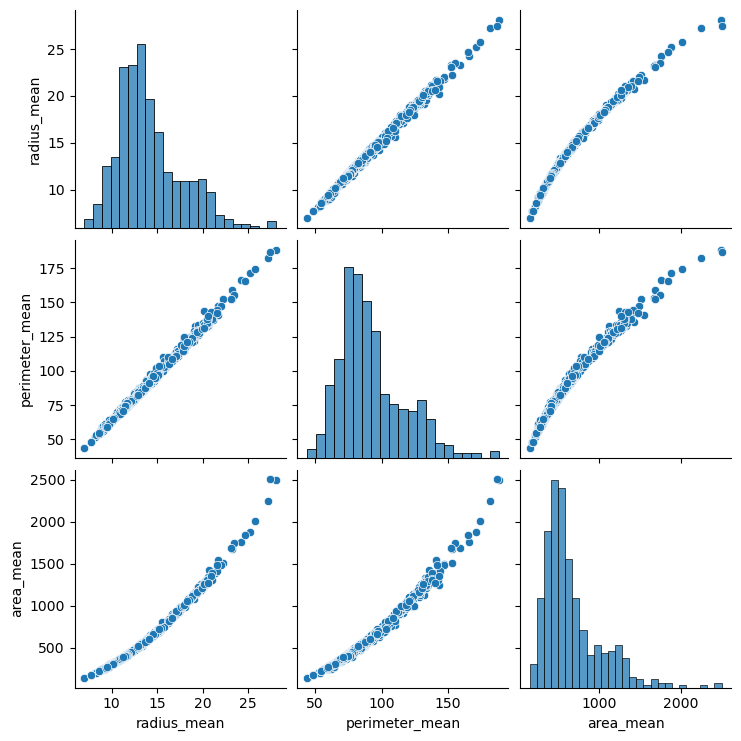

In [72]:
pair = ['radius_mean', 'perimeter_mean', 'area_mean']
sns.pairplot(df[pair])

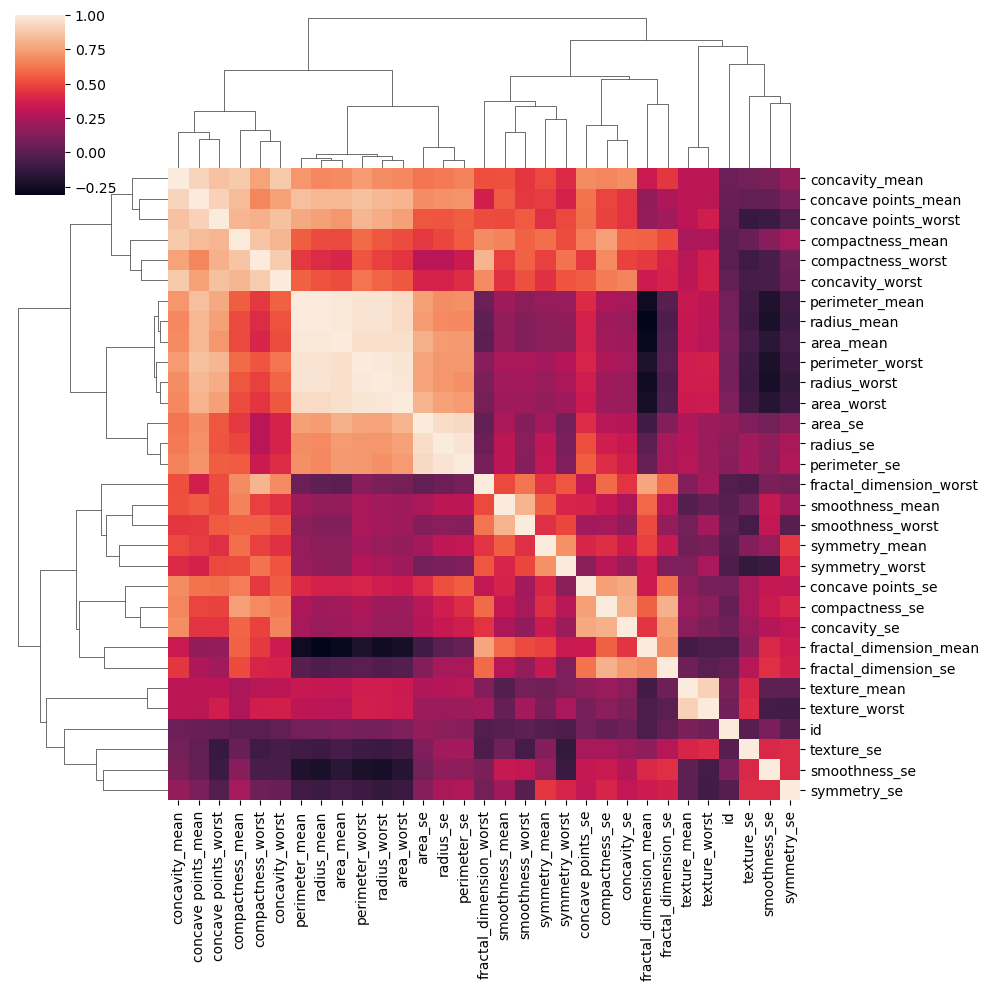

In [73]:
df_var = df.drop('diagnosis', axis = 1)
sns.clustermap(df_var.corr())  #version améliorée de heatmap qui permet de regrouper les variables par similarité

In [74]:
# t_test entre variables

def t_test(col):
    alpha = 0.05

# 2) Traintest, cleaning, encoding, preliminary models

In [75]:
trainset, testset = train_test_split(df, test_size = 0.2, random_state=0)

In [76]:
# Créer une fonction pour encoder le dataset, qu'on pourra réutiliser ensuite sur le testset

def encodage(df):
    code = {
    'B' : 1,
    'M' : 0
}
    
# Appliquer ce dictionnaire aux colonnes du dataset, avec la fonction map
    for col in df.select_dtypes('object'):
        df[col] = df[col].map(code)

    return df


# Créer une fonction qui performe le préprocessing, et créé les variables X_test et y_test
def preprocessing(df):
    df = encodage(df)

    X = df.drop('diagnosis', axis = 1)
    y = df['diagnosis']

    # compter le nombre d'échantillons restants dans le dataset après avoir été inputé
    print(y.value_counts())

    return X, y

In [77]:
X_train, y_train = preprocessing(trainset)
X_test, y_test = preprocessing(testset)

diagnosis
1    290
0    165
Name: count, dtype: int64
diagnosis
1    67
0    47
Name: count, dtype: int64


In [78]:
model = DecisionTreeClassifier(random_state=0)

In [79]:
pipe = make_pipeline(SelectKBest(f_classif, k = 15), model)

In [80]:
def evaluation(model):
    model.fit(X_train, y_train)
    ypred = model.predict(X_test)

    print(confusion_matrix(y_test, ypred))
    print(classification_report(y_test, ypred))

    # evaluation du modèle en fonction du nombre de samples, basé sur le f1 score
    # Evalue si underfit ou overfit
    N, train_score, val_score = learning_curve(model, X_train, y_train, cv=4, scoring='f1', train_sizes=np.linspace(0.1, 1, 10))

    plt.figure(figsize=(10,6))
    # on prend les .means de chaque round de cv. cv = 4 <=> on sépare le dataset en 4 et prend 3 part = train 1 part = test, puis on échange
    plt.plot(N, train_score.mean(axis=1), label = 'train score')
    plt.plot(N, val_score.mean(axis=1), label = 'val score')
    plt.legend()

[[44  3]
 [ 8 59]]
              precision    recall  f1-score   support

           0       0.85      0.94      0.89        47
           1       0.95      0.88      0.91        67

    accuracy                           0.90       114
   macro avg       0.90      0.91      0.90       114
weighted avg       0.91      0.90      0.90       114



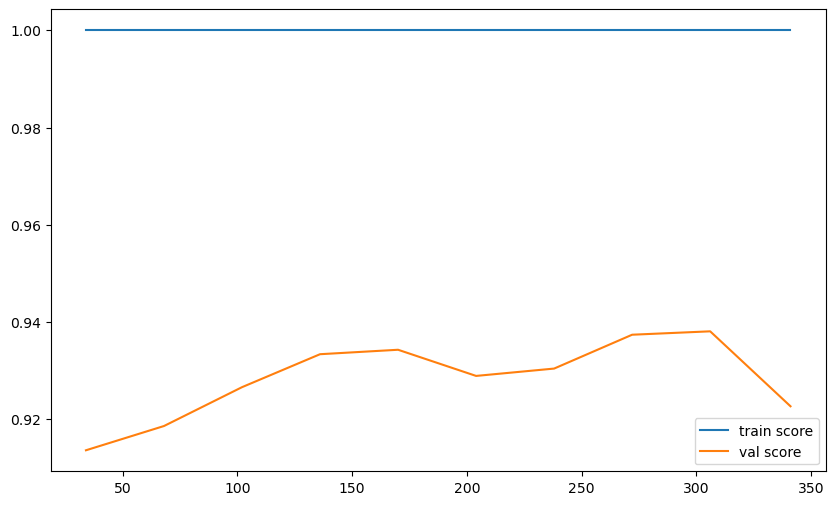

In [81]:
evaluation(model)

[[45  2]
 [ 4 63]]
              precision    recall  f1-score   support

           0       0.92      0.96      0.94        47
           1       0.97      0.94      0.95        67

    accuracy                           0.95       114
   macro avg       0.94      0.95      0.95       114
weighted avg       0.95      0.95      0.95       114



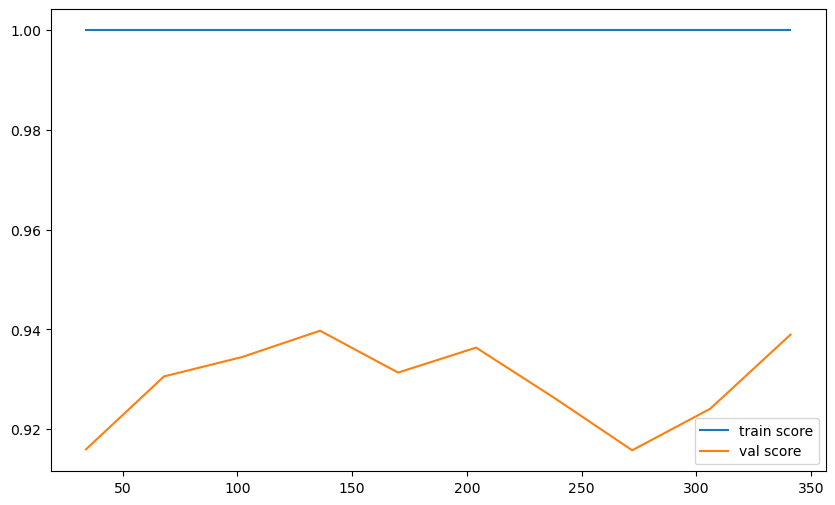

In [82]:
evaluation(pipe)

# 3) Model optimization

### Try different models

In [88]:
RandomForest = make_pipeline(SelectKBest(k=15), RandomForestClassifier(random_state = 0))
AdaBoost = make_pipeline(SelectKBest(k=15), AdaBoostClassifier(random_state = 0))
SVM = make_pipeline(SelectKBest(k=15), StandardScaler(), SVC(random_state = 0))
KNN = make_pipeline(SelectKBest(k=15), StandardScaler(), KNeighborsClassifier())
LR_L1 = make_pipeline(SelectKBest(k=15), StandardScaler(), LogisticRegression(penalty='l1', random_state = 0, solver = 'liblinear'))
LR_L2 = make_pipeline(SelectKBest(k=15), StandardScaler(), LogisticRegression(penalty='l2', random_state = 0, solver = 'liblinear'))
LR_EN = make_pipeline(SelectKBest(k=15), StandardScaler(), LogisticRegression(penalty='elasticnet', l1_ratio=0.5, random_state = 0, solver = 'saga'))


dict_of_models = {'RandomForest' : RandomForest, 
                  'AdaBoost' : AdaBoost, 
                  'SVM' : SVM, 
                  'KNN' : KNN,
                  'LR_L1' : LR_L1,
                  'LR_L2' : LR_L2,
                  'LR_EN' : LR_EN
                 }

In [ ]:
for name, models in dict_of_models.items():
    print(models)
    evaluation(models)

# SVC is the best

### Best model optimization

In [102]:
hyper_params = {'svc__gamma': [1e-3, 1e-4],
                'svc__C' : [1, 10, 100, 1000],
               'selectkbest__k' : range(4, 31)}

In [ ]:
grid = GridSearchCV(SVM, cv = 4, param_grid=hyper_params, scoring='f1')
grid.fit(X_train, y_train)
print(grid.best_params_)

[[46  1]
 [ 1 66]]
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        47
           1       0.99      0.99      0.99        67

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



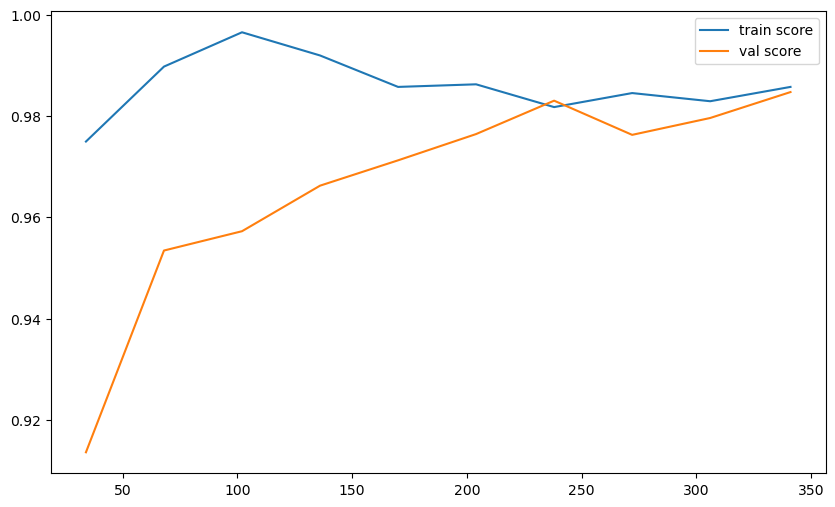

In [105]:
evaluation(grid.best_estimator_)